In [4]:
import pandas as pd

df = pd.read_csv("../data/Food_Delivery_Times.csv.csv")

print(df.head())

   Order_ID  Distance_km Weather Traffic_Level Time_of_Day Vehicle_Type  \
0       522         7.93   Windy           Low   Afternoon      Scooter   
1       738        16.42   Clear        Medium     Evening         Bike   
2       741         9.52   Foggy           Low       Night      Scooter   
3       661         7.44   Rainy        Medium   Afternoon      Scooter   
4       412        19.03   Clear           Low     Morning         Bike   

   Preparation_Time_min  Courier_Experience_yrs  Delivery_Time_min  
0                    12                     1.0                 43  
1                    20                     2.0                 84  
2                    28                     1.0                 59  
3                     5                     1.0                 37  
4                    16                     5.0                 68  


In [5]:
df.columns

Index(['Order_ID', 'Distance_km', 'Weather', 'Traffic_Level', 'Time_of_Day',
       'Vehicle_Type', 'Preparation_Time_min', 'Courier_Experience_yrs',
       'Delivery_Time_min'],
      dtype='str')

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Order_ID                1000 non-null   int64  
 1   Distance_km             1000 non-null   float64
 2   Weather                 970 non-null    str    
 3   Traffic_Level           970 non-null    str    
 4   Time_of_Day             970 non-null    str    
 5   Vehicle_Type            1000 non-null   str    
 6   Preparation_Time_min    1000 non-null   int64  
 7   Courier_Experience_yrs  970 non-null    float64
 8   Delivery_Time_min       1000 non-null   int64  
dtypes: float64(2), int64(3), str(4)
memory usage: 70.4 KB


In [7]:
df.isnull().sum()

Order_ID                   0
Distance_km                0
Weather                   30
Traffic_Level             30
Time_of_Day               30
Vehicle_Type               0
Preparation_Time_min       0
Courier_Experience_yrs    30
Delivery_Time_min          0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
print(df.columns)

Index(['Order_ID', 'Distance_km', 'Weather', 'Traffic_Level', 'Time_of_Day',
       'Vehicle_Type', 'Preparation_Time_min', 'Courier_Experience_yrs',
       'Delivery_Time_min'],
      dtype='str')


In [10]:
print(df.columns.tolist())

['Order_ID', 'Distance_km', 'Weather', 'Traffic_Level', 'Time_of_Day', 'Vehicle_Type', 'Preparation_Time_min', 'Courier_Experience_yrs', 'Delivery_Time_min']


In [11]:
df["Delivery_Time_min"].mean()

np.float64(56.732)

In [12]:
df["Delivery_Time_min"].median()

np.float64(55.5)

In [13]:
df["Delivery_Time_min"].std()

np.float64(22.07091528009886)

In [14]:
df["Delivery_Time_min"].var()

np.float64(487.12530130130136)

In [15]:
df["Delivery_Time_min"].quantile([0.25, 0.50, 0.75])

0.25    41.0
0.50    55.5
0.75    71.0
Name: Delivery_Time_min, dtype: float64

In [16]:
df["Delivery_Time_min"].mean()

np.float64(56.732)

In [17]:
df["Delivery_Time_min"].skew()

np.float64(0.5072511816152696)

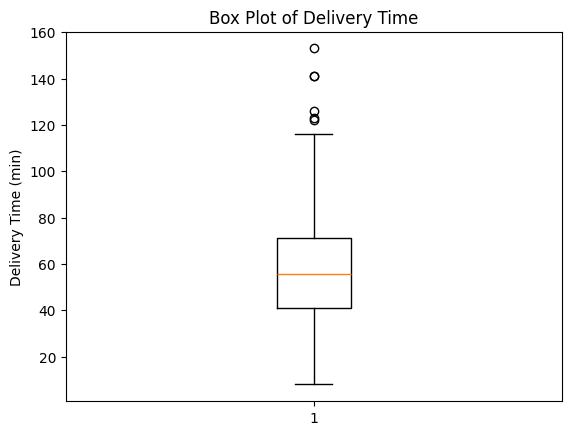

In [18]:
import matplotlib.pyplot as plt

plt.boxplot(df["Delivery_Time_min"])
plt.title("Box Plot of Delivery Time")
plt.ylabel("Delivery Time (min)")
plt.show()

In [19]:
Q1 = df["Delivery_Time_min"].quantile(0.25)
Q3 = df["Delivery_Time_min"].quantile(0.75)

IQR = Q3 - Q1

print("Q1 =", Q1)
print("Q3 =", Q3)
print("IQR =", IQR)

Q1 = 41.0
Q3 = 71.0
IQR = 30.0


In [20]:
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df["Delivery_Time_min"] < lower_bound) |
              (df["Delivery_Time_min"] > upper_bound)]

print("Number of Outliers:", len(outliers))
outliers

Number of Outliers: 6


,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
29,948,18.05,Clear,Medium,Evening,Scooter,10,7.0,123
127,446,18.97,Clear,Low,Evening,Car,25,4.0,141
379,814,18.46,Clear,NaN,NaN,Scooter,29,1.0,153
452,394,15.64,Rainy,Low,NaN,Bike,20,4.0,141
784,385,14.83,Rainy,Low,Morning,Car,19,4.0,126
924,428,17.81,Windy,High,Evening,Bike,21,4.0,122


In [21]:
from scipy.stats import zscore

df["Z_score"] = zscore(df["Delivery_Time_min"])

outliers_z = df[abs(df["Z_score"]) > 3]

print("Number of Outliers:", len(outliers_z))
outliers_z

Number of Outliers: 5


,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min,Z_score
29,948,18.05,Clear,Medium,Evening,Scooter,10,7.0,123,3.004006
127,446,18.97,Clear,Low,Evening,Car,25,4.0,141,3.819967
379,814,18.46,Clear,NaN,NaN,Scooter,29,1.0,153,4.363941
452,394,15.64,Rainy,Low,NaN,Bike,20,4.0,141,3.819967
784,385,14.83,Rainy,Low,Morning,Car,19,4.0,126,3.139999


In [22]:
outliers.sort_values("Delivery_Time_min", ascending=False)

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
379,814,18.46,Clear,NaN,NaN,Scooter,29,1.0,153
127,446,18.97,Clear,Low,Evening,Car,25,4.0,141
452,394,15.64,Rainy,Low,NaN,Bike,20,4.0,141
784,385,14.83,Rainy,Low,Morning,Car,19,4.0,126
29,948,18.05,Clear,Medium,Evening,Scooter,10,7.0,123
924,428,17.81,Windy,High,Evening,Bike,21,4.0,122


In [23]:
print(df.columns.tolist())

['Order_ID', 'Distance_km', 'Weather', 'Traffic_Level', 'Time_of_Day', 'Vehicle_Type', 'Preparation_Time_min', 'Courier_Experience_yrs', 'Delivery_Time_min', 'Z_score']


In [24]:
numeric_df = df.select_dtypes(include='number')

numeric_df.corr()

,Order_ID,Distance_km,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min,Z_score
Order_ID,1.000000,-0.024483,-0.035100,0.013152,-0.036650,-0.036650
Distance_km,-0.024483,1.000000,-0.009037,-0.007842,0.780998,0.780998
Preparation_Time_min,-0.035100,-0.009037,1.000000,-0.030830,0.307350,0.307350
Courier_Experience_yrs,0.013152,-0.007842,-0.030830,1.000000,-0.090433,-0.090433
Delivery_Time_min,-0.036650,0.780998,0.307350,-0.090433,1.000000,1.000000
Z_score,-0.036650,0.780998,0.307350,-0.090433,1.000000,1.000000


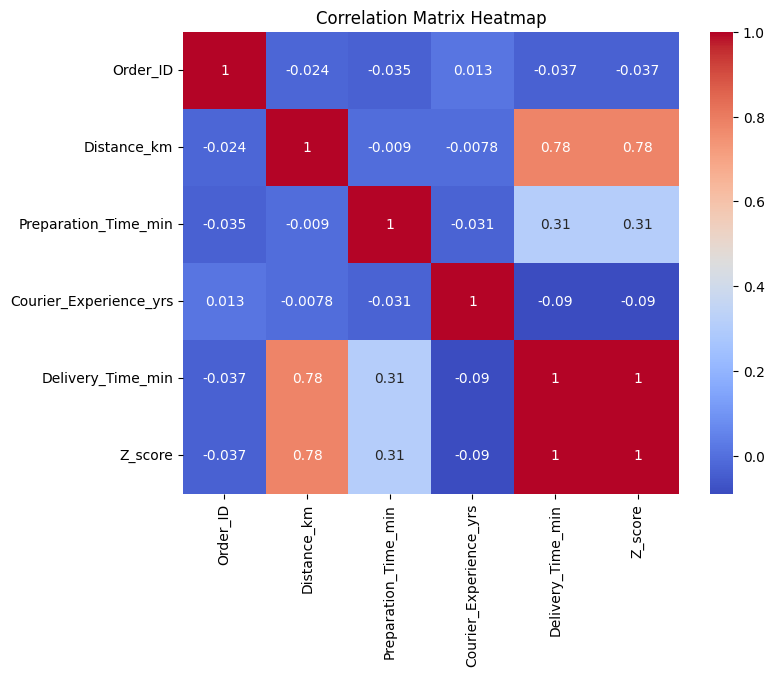

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix Heatmap")
plt.show()

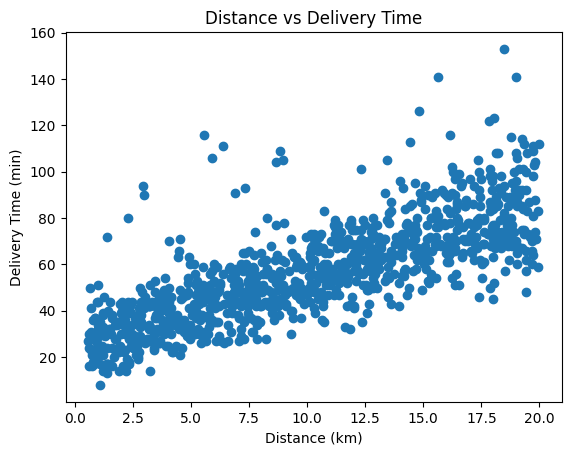

In [26]:
import matplotlib.pyplot as plt

plt.scatter(df["Distance_km"], df["Delivery_Time_min"])
plt.xlabel("Distance (km)")
plt.ylabel("Delivery Time (min)")
plt.title("Distance vs Delivery Time")
plt.show()

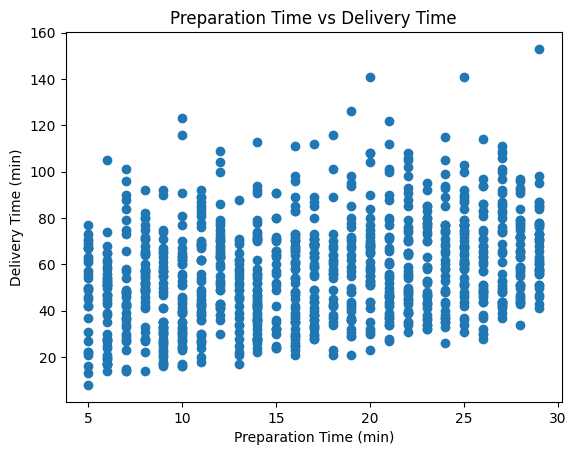

In [27]:
plt.scatter(df["Preparation_Time_min"], df["Delivery_Time_min"])
plt.xlabel("Preparation Time (min)")
plt.ylabel("Delivery Time (min)")
plt.title("Preparation Time vs Delivery Time")
plt.show()

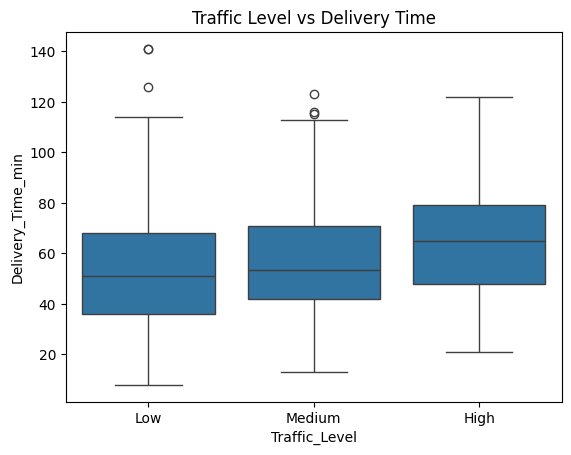

In [28]:
import seaborn as sns

sns.boxplot(x=df["Traffic_Level"], y=df["Delivery_Time_min"])
plt.title("Traffic Level vs Delivery Time")
plt.show()

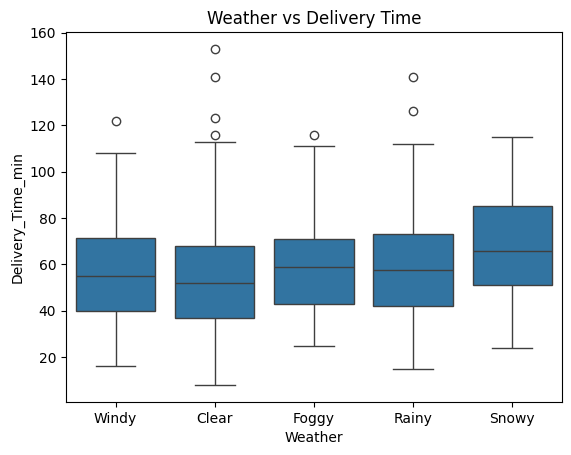

In [29]:
sns.boxplot(x=df["Weather"], y=df["Delivery_Time_min"])
plt.title("Weather vs Delivery Time")
plt.show()

In [30]:
print(df["Weather"].unique())

<StringArray>
['Windy', 'Clear', 'Foggy', 'Rainy', 'Snowy', nan]
Length: 6, dtype: str


In [31]:
from scipy.stats import f_oneway

groups = [group["Delivery_Time_min"].values
          for name, group in df.groupby("Weather")]

f_stat, p_value = f_oneway(*groups)

print("F-statistic:", f_stat)
print("P-value:", p_value)

F-statistic: 10.456546740984802
P-value: 2.7040565636023343e-08


In [32]:
alpha = 0.05

if p_value < alpha:
    print("Reject H0")
    print("Weather significantly affects delivery delay.")
else:
    print("Fail to Reject H0")
    print("Weather does not significantly affect delivery delay.")

Reject H0
Weather significantly affects delivery delay.


In [33]:
from scipy.stats import ttest_ind

low_traffic = df[df["Traffic_Level"]=="Low"]["Delivery_Time_min"]
high_traffic = df[df["Traffic_Level"]=="High"]["Delivery_Time_min"]

t_stat, p_value = ttest_ind(low_traffic, high_traffic)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: -6.252762162818076
P-value: 7.842356163075621e-10


In [34]:
if p_value < 0.05:
    print("Reject H0")
else:
    print("Fail to Reject H0")

Reject H0


In [35]:
import pandas as pd
from scipy.stats import chi2_contingency

table = pd.crosstab(df["Weather"], df["Traffic_Level"])

print(table)

Traffic_Level  High  Low  Medium
Weather                         
Clear            83  177     193
Foggy            21   47      34
Rainy            44   80      74
Snowy            20   44      30
Windy            23   26      44


In [36]:
chi2, p_value, dof, expected = chi2_contingency(table)

print("Chi-square:", chi2)
print("P-value:", p_value)

Chi-square: 12.739723288836327
P-value: 0.12112422627545961


In [37]:
if p_value < 0.05:
    print("Reject H0")
    print("Variables are associated")
else:
    print("Fail to Reject H0")
    print("Variables are independent")

Fail to Reject H0
Variables are independent
